In [2]:
import seaborn as sns
sns.set_theme(style="white", palette="muted", font_scale=0.8)

import mpl_fontkit as fk
# 1. Install and register Inter
fk.install("Inter")  
fk.set_font("Inter")  

import matplotlib.pyplot as plt

# # — Use TrueType embedding (requires matplotlib≥3.10.1):
# plt.rcParams['pdf.fonttype'] = 3
# plt.rcParams['ps.fonttype']  = 3


# Set the default font size for all plots
plt.rcParams['font.size'] = 10

textwidth = 6.32283  # inches from 455,24411 pt textwidth in the document
# set default figure width to textwidth
plt.rcParams['figure.figsize'] = (textwidth, textwidth * 0.618)  # golden ratio
plt.rcParams['figure.dpi'] = 300  # high-quality output

color_array = sns.color_palette("muted", 10)

Font name: `Inter`


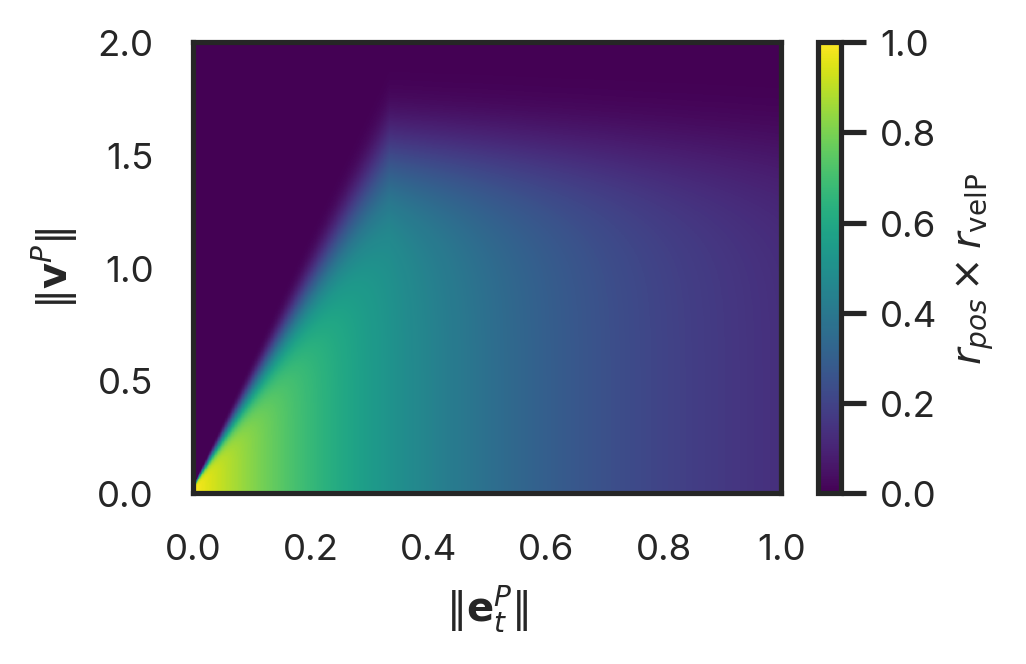

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def tracking_reward(dis, s=2, coef=1.0):
    """Distance-based exponential tracking reward."""
    return coef * np.exp(-s * np.abs(dis))

def vel_reward(vel, dis, max_vel=1.5):
    """Velocity-based reward penalizing high speeds relative to distance."""
    denom = np.minimum(3 * dis, 1) + 0.02
    return np.exp(-((vel / denom) / max_vel) ** 8)

# Create grid of distances and velocities
distances = np.linspace(0, 1, 1000)
velocities = np.linspace(0, 2, 1000)  # Extended range to 2 m/s
D, V = np.meshgrid(distances, velocities)

# Compute combined reward
R = tracking_reward(D) * vel_reward(V, D)

# Plot heatmap as pixels
fig = plt.figure(figsize=(textwidth*0.5, textwidth *0.5 * 0.618),constrained_layout=True)  # adjust size/golden ratio as desired
ax = fig.add_subplot(1, 1, 1)
im = ax.imshow(
    R,
    origin='lower',
    extent=[distances.min(), distances.max(), velocities.min(), velocities.max()],
    aspect='auto',
    interpolation='nearest',  # render as blocky pixels
    cmap='viridis'
)
ax.set_xlabel(r'$\|\mathbf{e}^P_t\|$')
ax.set_ylabel(r'$\|\mathbf{v}^P\|$')
ax.set_ylim(0, 2)  # Set y-axis limit to 2 m/s

cb = fig.colorbar(im, ax=ax)
cb.set_label(r'$r_{pos} \times r_{\mathrm{velP}}$')

# Save figure (ensure the 'out' directory exists)
fig.savefig('out/reward_heatmap.pdf') 

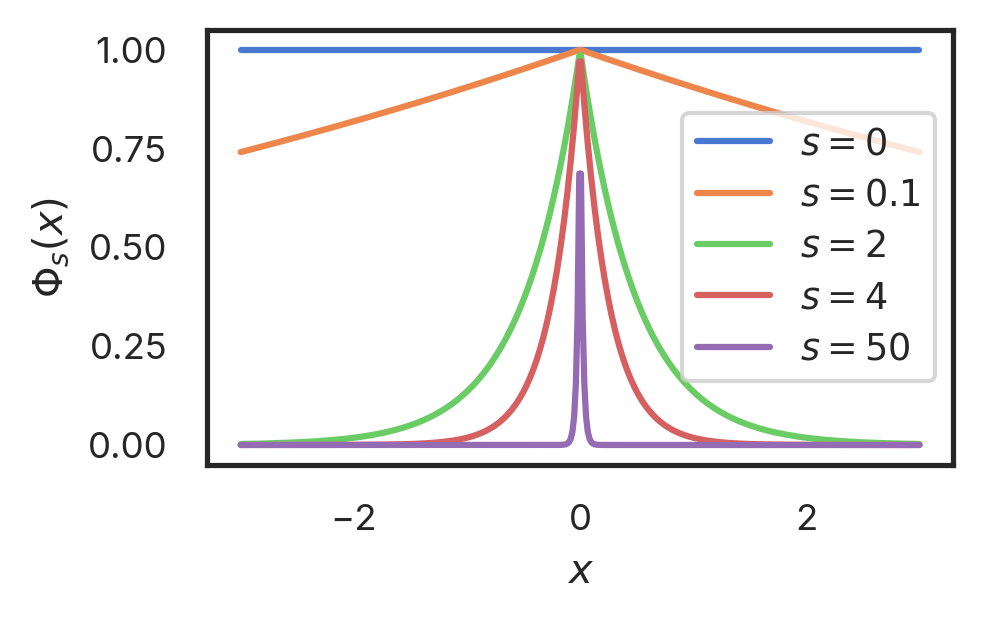

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure mathtext is used, not external LaTeX
plt.rcParams['text.usetex'] = False

def Phi_s(x, s):
    return np.exp(-s * np.abs(x))

# Define x range and s values
x = np.linspace(-3, 3, 400)
ss = [0, 0.1,2, 4, 50]

# Plot
plt.figure(figsize=(textwidth*0.5, textwidth *0.5 * 0.618),constrained_layout=True)
for s in ss:
    plt.plot(x, Phi_s(x, s), label=rf'$s={s}$')
plt.xlabel(r'$x$')
plt.ylabel(r'$\Phi_s(x)$')

plt.legend()

plt.savefig('out/phi.pdf')